## **1. Projeto de Machine Learning I 2025/2026: Avaliação e Adaptação de Algoritmos de Classificação**

**Universidade do Porto (U. PORTO)**  
**Unidade Curricular:** Machine Learning I (CC2008)  
**Turma:** PL3 | **Grupo:** PL3_G1  
**Docente:** Rita Paula Almeida Ribeiro  

### **Equipa de Desenvolvimento**
| Número | Nome |
| :--- | :--- |
| **202300276** | Guilherme Klippel |
| **202304280** | Daniel Tiago |
| **202512256** | Lucas Coelho |

---

### **Introdução e Contexto do Problema**

Os algoritmos de classificação supervisionada enfrentam diversos desafios em cenários reais, incluindo ruído, *outliers*, desbalanceamento de classes e a natureza multiclasse dos problemas. Este projeto investiga o impacto destas características no desempenho de um algoritmo clássico — a **Logistic Regression** — e propõe uma adaptação para lidar com a **classificação multiclasse** (Grupo de Datasets 3).

O trabalho organiza-se em duas fases:

1. **Fase 1 — Baseline.** Implementação da Logistic Regression a partir do zero, construção de uma *pipeline* de pré-processamento (imputação, *encoding*, normalização) e avaliação empírica do desempenho do algoritmo nos 45 *datasets* multiclasse fornecidos.

2. **Fase 2 — Proposta de Melhoria.** Identificação das limitações estruturais do algoritmo binário em contextos multiclasse, proposta e implementação de uma variante adaptada — a **Softmax Regression** — seguida de uma extensão original com **ponderação por classe** (*Weighted Softmax*) para mitigar o efeito do desbalanceamento. A análise é validada através de testes estatísticos de hipótese (Wilcoxon Signed-Rank) e ilustrada com um estudo de caso aplicado.

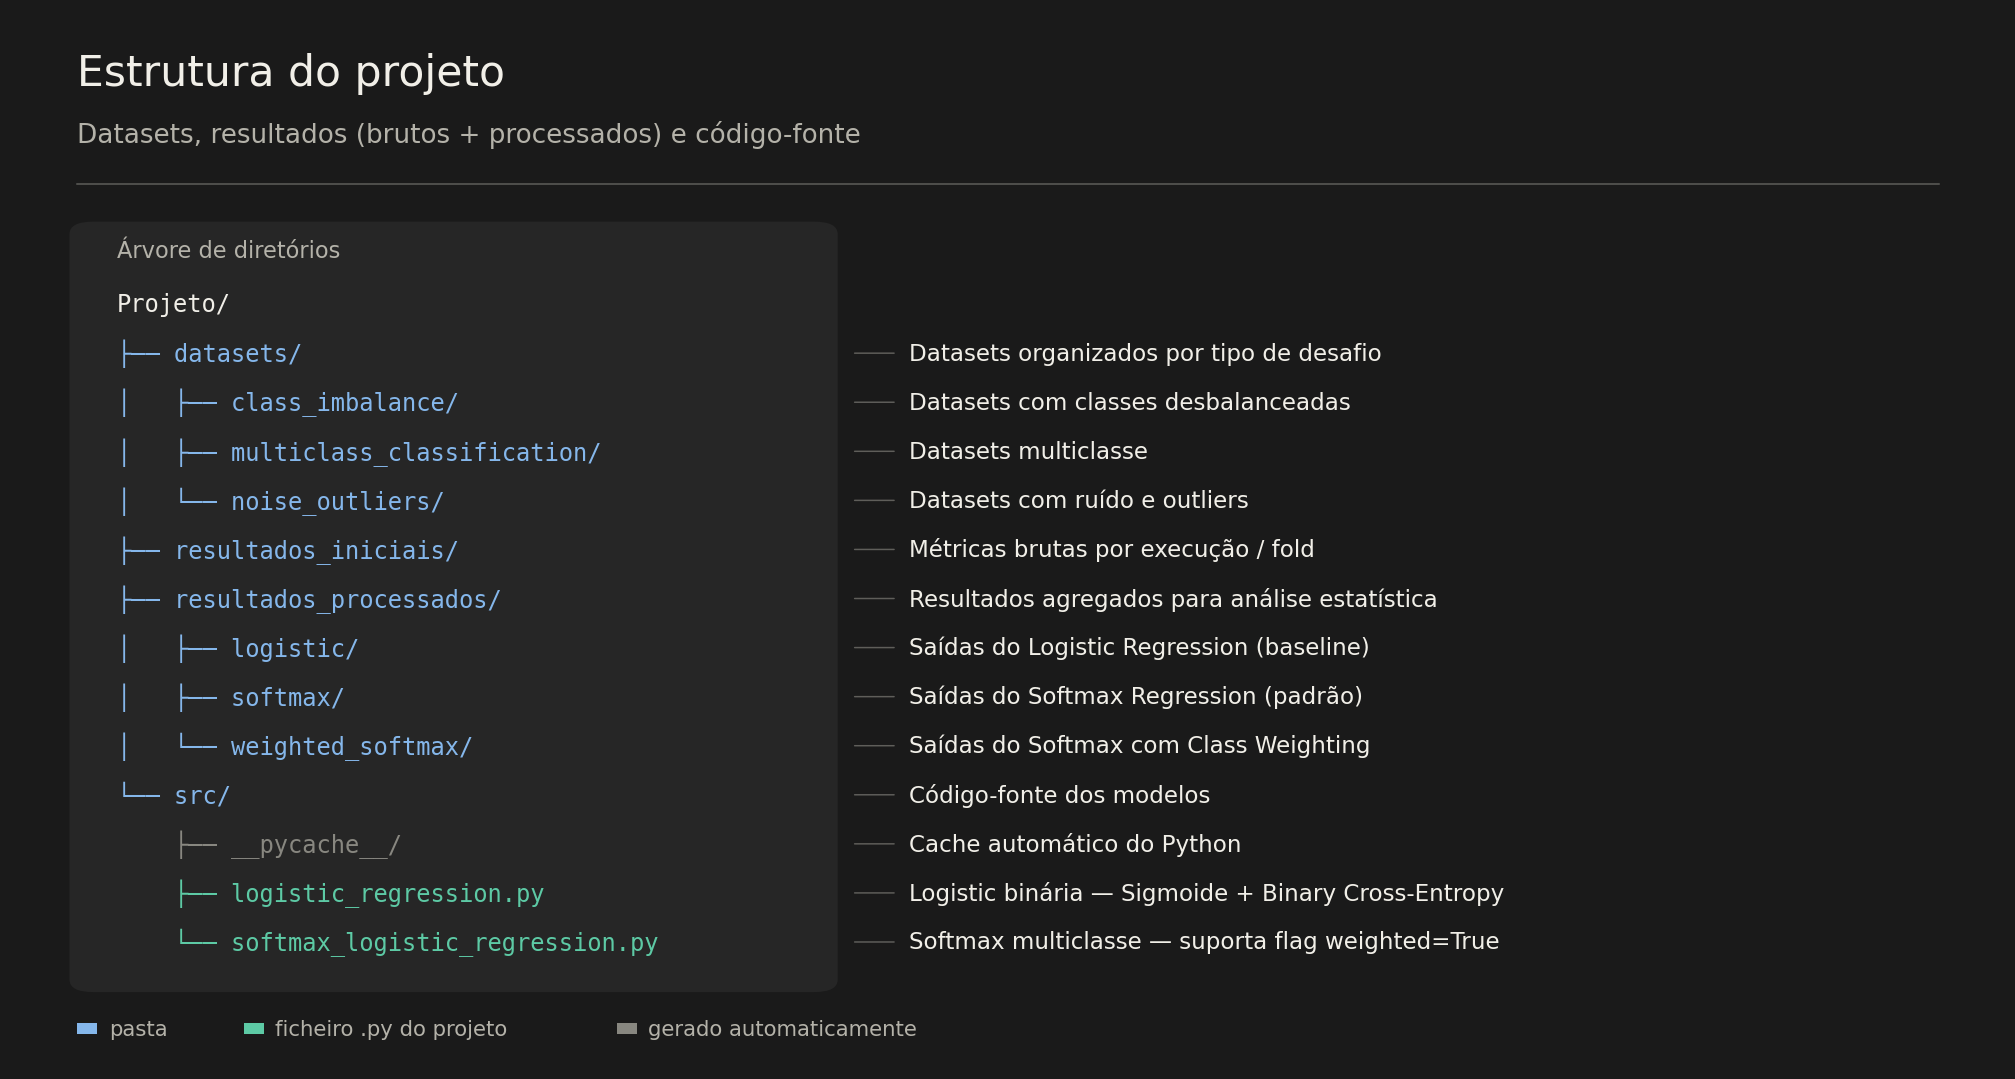

##### Importes 

In [4]:
%matplotlib inline 
%load_ext autoreload
%autoreload 2
import os
import time
import numpy as np
import pandas as pd
from IPython.display import display 
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
sns.set_theme(style="whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix, 
    classification_report
)
from src.logistic_regression import LogisticRegression
from src.softmax_logistic_regression import SoftmaxRegression  # <-- NOVA LINHA

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 2. Tratamento da Baseline e Pré-Processamento

In [5]:
exemplo_path = r"E:\FCUP\AC1\Projeto\datasets\multiclass_classification\dataset_381_ipums_la_98-small.csv"

# Carregar Dados
df_exemplo = pd.read_csv(exemplo_path)
X_df = df_exemplo.iloc[:, :-1].copy()
y_df = df_exemplo.iloc[:, -1].copy()

# 1. Informações Estruturais
print(f"Dimensões originais - Amostras(Linhas): {X_df.shape[0]}, Features(Colunas): {X_df.shape[1]}")
print(f"Total de valores nulos (NaN): {X_df.isnull().sum().sum()}")

# 2. Análise dos Tipos de Dados
tipos_dados = X_df.dtypes.value_counts()
for tipo, contagem in tipos_dados.items():
    print(f"- {tipo}: {contagem} coluna(s)")

# 3. Verificação do Target (y)
print(f"Tipo de dado do Target (y): {y_df.dtype}")

Dimensões originais - Amostras(Linhas): 7485, Features(Colunas): 60
Total de valores nulos (NaN): 52048
- int64: 34 coluna(s)
- object: 26 coluna(s)
Tipo de dado do Target (y): int64



### Tratamento dos Valores Nulos
* Variáveis Numéricas (Imputação pela Mediana)

O que fizemos: Substituímos os valores nulos pelo valor central da coluna (a mediana).

Por quê: Ao contrário da média, a mediana é robusta a outliers (valores extremos). Em um dataset real, onde podem existir ruídos ou valores atípicos, a média pode ser "puxada" para longe da realidade, enquanto a mediana mantém a representatividade estatística da maioria dos dados.

* Variáveis Categóricas ou de Texto (Imputação pela Moda)

O que fizemos: Substituímos os valores nulos (NaNs) pelo valor que mais se repete na coluna (a moda).

Por quê: Para dados do tipo texto (strings ou objects), não é possível realizar operações matemáticas. A moda é a escolha mais lógica para manter a consistência categórica, partindo da premissa de que a falta de um dado tem maior probabilidade de pertencer à classe mais comum daquela coluna.

In [6]:
def imputar_nulos(df):
    """
    Função pura que substitui NaNs pela mediana (numéricos) ou moda (categóricos).
    Retorna o DataFrame limpo e os índices das linhas que foram alteradas.
    """
    df_clean = df.copy()
    indices_nulos = df_clean[df_clean.isnull().any(axis=1)].index
    
    cols_num = df_clean.select_dtypes(include=[np.number]).columns
    cols_cat = df_clean.select_dtypes(exclude=[np.number]).columns
    
    if len(cols_num) > 0:
        df_clean[cols_num] = df_clean[cols_num].fillna(df_clean[cols_num].median())
        
    for col in cols_cat:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
            
    return df_clean, indices_nulos

##### Exemplo Prático

In [7]:
# 1. Chamar a função usando o X_df que já está na memória
X_limpo, linhas_alteradas = imputar_nulos(X_df)

# 2. Imprimir os resultados e analisar (EDA)
print(f"Total de NaNs ANTES da limpeza: {X_df.isnull().sum().sum()}")
print(f"Total de NaNs DEPOIS da limpeza: {X_limpo.isnull().sum().sum()}")

if len(linhas_alteradas) > 0:
    print("\n--- ANTES da limpeza (As linhas que tinham NaNs): ---")
    # Mostra o X_df original
    display(X_df.loc[linhas_alteradas].head(5))
    
    print("\n--- DEPOIS da limpeza (As mesmas linhas corrigidas): ---")
    # Mostra o X_limpo
    display(X_limpo.loc[linhas_alteradas].head(5))
else:
    print("\nO dataset não tinha valores nulos.")

Total de NaNs ANTES da limpeza: 52048
Total de NaNs DEPOIS da limpeza: 0

--- ANTES da limpeza (As linhas que tinham NaNs): ---


,year,gq,gqtypeg,farm,ownershg,value,rent,ftotinc,nfams,ncouples,...,incbus,incfarm,incss,incwelfr,incother,poverty,migrat5g,migplac5,vetstat,tranwork
0,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,325,9505,1,1,...,0,0,0,0,0,128,Same_state_countydifferent_house,California,No_Service,NaN
1,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,287,8005,1,0,...,0,0,0,0,0,211,NaN,NaN,No_Service,NaN
2,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),85000,0,29635,1,1,...,999999,999999,99999,99999,99999,304,NaN,NaN,NaN,NaN
3,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),999999,0,52895,1,1,...,0,0,0,0,0,501,Same_house,Same_house,No_Service,NaN
4,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,185,7610,2,0,...,0,0,0,0,0,119,NaN,NaN,No_Service,Auto



--- DEPOIS da limpeza (As mesmas linhas corrigidas): ---


,year,gq,gqtypeg,farm,ownershg,value,rent,ftotinc,nfams,ncouples,...,incbus,incfarm,incss,incwelfr,incother,poverty,migrat5g,migplac5,vetstat,tranwork
0,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,325,9505,1,1,...,0,0,0,0,0,128,Same_state_countydifferent_house,California,No_Service,Auto
1,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,287,8005,1,0,...,0,0,0,0,0,211,Same_house,Same_house,No_Service,Auto
2,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),85000,0,29635,1,1,...,999999,999999,99999,99999,99999,304,Same_house,Same_house,No_Service,Auto
3,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),999999,0,52895,1,1,...,0,0,0,0,0,501,Same_house,Same_house,No_Service,Auto
4,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,185,7610,2,0,...,0,0,0,0,0,119,Same_house,Same_house,No_Service,Auto


### Conversão de Texto para Números (One-Hot Encoding)
O nosso algoritmo matemático não compreende *strings* (variáveis do tipo `object`). Para resolver isto, aplicamos a técnica de **One-Hot Encoding** usando a função `get_dummies` do pandas.

* O que faz: Cria uma nova coluna binária (0 ou 1) para cada categoria de texto.
* Prevenção de Colinearidade: Utilizamos o parâmetro `drop_first=True` para evitar a "Armadilha das Variáveis Dummy" (*Dummy Variable Trap*), garantindo que as novas colunas não sejam perfeitamente correlacionadas, o que desestabilizaria o modelo matemático.

In [8]:
def aplicar_encoding(X_df, y_df):
    """
    Função pura: Aplica One-Hot Encoding nas features categóricas (X) e
    converte a variável alvo (y) para numérico. 
    Retorna o DataFrame transformado, as matrizes Numpy e as colunas originais.
    """
    X_clean = X_df.copy()
    y_clean = y_df.copy()
    
    # 1. Identificar as colunas de texto
    cols_cat = X_clean.select_dtypes(exclude=[np.number]).columns
    
    # 2. Aplicar o Encoding
    if len(cols_cat) > 0:
        X_clean = pd.get_dummies(X_clean, columns=cols_cat, drop_first=True)
    
    # 3. Converter tudo para Float (necessário para o Gradient Descent)
    X_clean = X_clean.astype(float)
    X_numpy = X_clean.values
    
    # 4. Tratar a variável alvo (y)
    if y_clean.dtype == 'object':
        y_numpy = pd.factorize(y_clean)[0]
    else:
        y_numpy = y_clean.values
        
    return X_clean, X_numpy, y_numpy, cols_cat

##### Exemplo Prático

In [9]:
# --- 1. Ver o ANTES ---
cols_cat = X_limpo.select_dtypes(exclude=[np.number]).columns
if len(cols_cat) > 0:
    print("--- ANTES do One-Hot Encoding (Apenas as colunas de texto) ---")
    display(X_limpo[cols_cat].head(5))
else:
    print("--- Não foram encontradas colunas de texto neste dataset. ---")

print(f"\nNúmero de colunas originais: {X_limpo.shape[1]}")

# --- 2. Executar a função ---
# Passamos o X_limpo e o y_df (que carregaste na 1ª célula do Notebook)
X_df_encoded, X_numpy, y_numpy, colunas_cat = aplicar_encoding(X_limpo, y_df)

# --- 3. Ver o DEPOIS ---
print(f"\n--- DEPOIS do One-Hot Encoding ---")
print(f"O número de features (colunas) saltou para {X_df_encoded.shape[1]}!")
print("Como o dataset numérico ficou agora:")
display(X_df_encoded.head(5))

# As variáveis finais prontas para o modelo são 'X_numpy' e 'y_numpy'

--- ANTES do One-Hot Encoding (Apenas as colunas de texto) ---


,gq,gqtypeg,farm,ownershg,relateg,sex,raceg,marst,chborn,bplg,...,ind1950,classwkg,wkswork2,hrswork2,yrlastwk,workedyr,migrat5g,migplac5,vetstat,tranwork
0,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,Spouse,Female,White,Married_spouse_present,2__children,California,...,Food_stores_except_dairy,Works_for_wages_salary,50-52_weeks,40_hours,Worked_3-5_yrs_ago,No,Same_state_countydifferent_house,California,No_Service,Auto
1,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,Head_Householder,Female,Black_Negro,Never_married_single,No_children,California,...,Crude_petroleum_and_natural_gas_extraction,Works_for_wages_salary,40-47_weeks,40_hours,Worked_current_yr,Yes,Same_house,Same_house,No_Service,Auto
2,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),Child,Female,White,Never_married_single,No_children,California,...,Educational_services,Works_for_wages_salary,50-52_weeks,40_hours,Worked_more_than_10_yrs_ago,Yes,Same_house,Same_house,No_Service,Auto
3,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),Child,Male,White,Never_married_single,No_children,California,...,Educational_services,Works_for_wages_salary,50-52_weeks,40_hours,Never_worked,No,Same_house,Same_house,No_Service,Auto
4,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,Partner_friend_visitor,Female,White,Never_married_single,No_children,California,...,Hospitals,Works_for_wages_salary,40-47_weeks,15-29_hours,Worked_more_than_10_yrs_ago,Yes,Same_house,Same_house,No_Service,Auto



Número de colunas originais: 60

--- DEPOIS do One-Hot Encoding ---
O número de features (colunas) saltou para 596!
Como o dataset numérico ficou agora:


,year,value,rent,ftotinc,nfams,ncouples,nmothers,nfathers,momloc,stepmom,...,vetstat_Yes,tranwork_Bicycle,tranwork_Bus_or_streetcar,tranwork_Motorcycle,tranwork_Other,tranwork_Taxicab,tranwork_Truck,tranwork_Van,tranwork_Walked_only,tranwork_Worked_at_home
0,98.0,999999.0,325.0,9505.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,98.0,999999.0,287.0,8005.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,98.0,85000.0,0.0,29635.0,1.0,1.0,1.0,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,98.0,999999.0,0.0,52895.0,1.0,1.0,1.0,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,98.0,999999.0,185.0,7610.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Normalização
Aplicamos a normalização Z-Score para colocar todas as variáveis numéricas na mesma escala matemática (garantindo média igual a 0 e desvio padrão igual a 1). Isso impede que o algoritmo dê mais importância a uma variável apenas por ela ter valores absolutos maiores (como "Salário" vs "Idade").

In [10]:
def normalizar_zscore(X_train, X_test):
    """
    Aplica a escala Z-Score (StandardScaler).
    Retorna os dados escalados e os parâmetros estatísticos.
    """
    # 1. Calcular parâmetros APENAS no treino (evita Data Leakage)
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    
    # Prevenir divisão por zero caso uma feature seja constante
    sigma[sigma == 0] = 1e-8 
    
    # 2. Aplicar a transformação: z = (x - mu) / sigma
    X_train_s = (X_train - mu) / sigma
    X_test_s = (X_test - mu) / sigma
    
    return X_train_s, X_test_s, mu, sigma


#### Exemplo Prático

In [11]:
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_numpy, y_numpy, test_size=0.3, stratify=y_numpy, random_state=42
)

print("--- ANTES da Normalização ---")
print(f"Média da 1ª feature: {np.mean(X_tr_raw[:, 0]):.2f}")
print(f"Desvio Padrão da 1ª feature: {np.std(X_tr_raw[:, 0]):.2f}")

# Chamamos a função (agora os dados são 100% numéricos)
X_train, X_test, mu, sigma = normalizar_zscore(X_tr_raw, X_te_raw)

print("\n--- DEPOIS da Normalização ---")
print(f"Média final: {np.mean(X_train[:, 0]):.10f}")
print(f"Desvio Padrão final: {np.std(X_train[:, 0]):.10f}")

--- ANTES da Normalização ---
Média da 1ª feature: 98.00
Desvio Padrão da 1ª feature: 0.00

--- DEPOIS da Normalização ---
Média final: 0.0000000000
Desvio Padrão final: 0.0000000000


### K-FOLD Cross-Validation
A função `avaliar_kfold` é o nosso "teste de estresse". Em vez de separar os dados apenas uma vez em treino e teste (o que poderia gerar um resultado de "sorte"), dividimos a base de dados em K pedaços (folds). O modelo treina em $K-1$ pedaços e faz a prova final no pedaço que sobrou, repetindo esse processo até que todos os pedaços tenham sido usados como teste.

In [12]:
def avaliar_kfold(X, y, algoritmo='logistic', n_splits=5, lr=0.01, max_iters=1000, random_state=42):
    """
    Função pura: Executa o K-Fold Cross-Validation com normalização local.
    
    Parâmetros:
        algoritmo: 'logistic' (binário), 'softmax' (multiclasse baseline) 
                   ou 'weighted_softmax' (multiclasse com class weighting)
    
    Retorna o DataFrame de métricas, a lista de modelos treinados e os 
    dados da última iteração (para podermos desenhar gráficos depois).
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []
    modelos = []
    
    # Variáveis para guardar os dados do último fold (útil para os gráficos)
    X_te_last, y_te_last, y_pred_last = None, None, None

    for i, (train_idx, test_idx) in enumerate(kf.split(X)):
        # 1. Divisão
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # 2. Normalização Z-Score (USANDO A NOSSA FUNÇÃO)
        X_tr_s, X_te_s, mu, sigma = normalizar_zscore(X_tr, X_te)

        # 3. Treino — escolhe o modelo conforme o parâmetro 'algoritmo'
        if algoritmo == 'logistic':
            model = LogisticRegression(lr=lr, max_iters=max_iters)
        elif algoritmo == 'softmax':
            model = SoftmaxRegression(lr=lr, max_iters=max_iters, weighted=False)        
        elif algoritmo == 'weighted_softmax':                                              
            model = SoftmaxRegression(lr=lr, max_iters=max_iters, weighted=True)           
        else:
            raise ValueError(f"Algoritmo desconhecido: '{algoritmo}'. Usa 'logistic', 'softmax' ou 'weighted_softmax'.")
        
        model.fit(X_tr_s, y_tr)
        modelos.append(model)

        # 4. Previsão e Métricas
        y_pred = model.predict(X_te_s)
        acc = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_te, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_te, y_pred, average='macro', zero_division=0)

        fold_results.append({
            'Fold': i + 1,
            'Accuracy': acc, 
            'Precision': prec, 
            'Recall': rec, 
            'F1-Score': f1
        })
        
        # Guardamos sempre os últimos dados processados
        X_te_last, y_te_last, y_pred_last = X_te_s, y_te, y_pred

    # Formatamos a tabela de resultados
    df_folds = pd.DataFrame(fold_results)
    df_folds.set_index('Fold', inplace=True)

    return df_folds, modelos, (X_te_last, y_te_last, y_pred_last)

#### Exemplo Prático

A treinar e avaliar o modelo base com 5-Folds. Por favor aguarda...

--- RESULTADOS DETALHADOS (FOLD A FOLD) ---


,Accuracy,Precision,Recall,F1-Score
Fold,,,,
1,0.555110,0.162009,0.240978,0.156914
2,0.580494,0.167465,0.246128,0.165583
3,0.575150,0.170070,0.246232,0.169826
4,0.567134,0.167640,0.244180,0.164346
5,0.557782,0.167315,0.244825,0.164130



--- PERFORMANCE CONSOLIDADA (Média e Desvio Padrão) ---


,Média (Final),Desvio Padrão
Accuracy,0.567134,0.010895
Precision,0.166900,0.002958
Recall,0.244469,0.002136
F1-Score,0.164160,0.004655


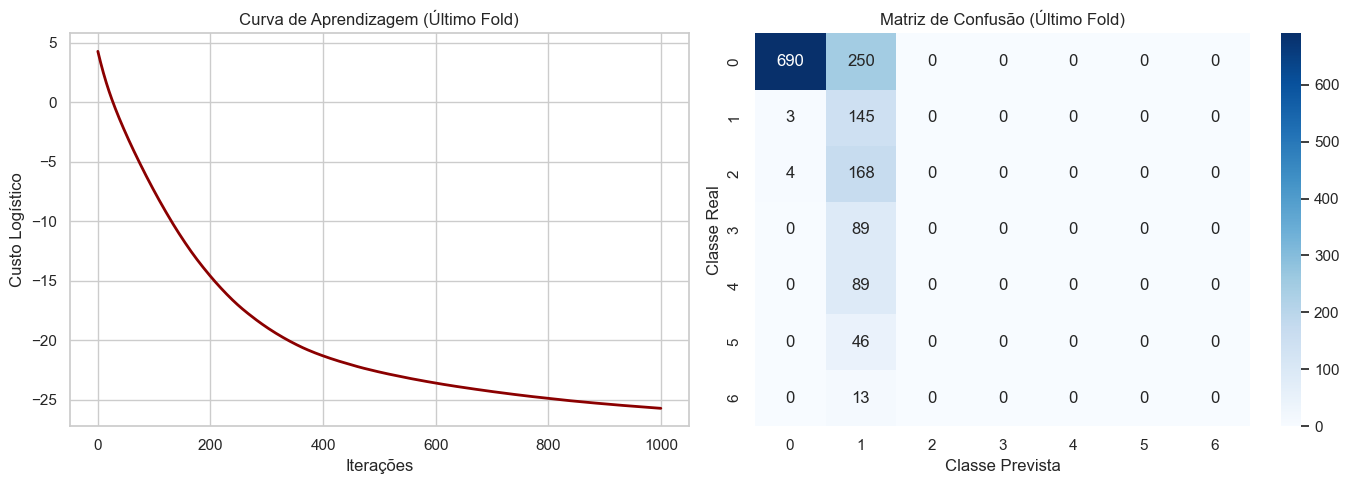

In [13]:
print("A treinar e avaliar o modelo base com 5-Folds. Por favor aguarda...\n")

# 1. Chamar a função pura (usando o X_numpy e y_numpy que saíram da célula de Encoding)
df_resultados_kf, modelos_treinados, ultimo_fold = avaliar_kfold(X_numpy, y_numpy, n_splits=5)
X_te_last, y_te_last, y_pred_last = ultimo_fold

# 2. Imprimir os resultados (Aqui estão os teus prints do K-Fold!)
print("--- RESULTADOS DETALHADOS (FOLD A FOLD) ---")
display(df_resultados_kf)

print("\n--- PERFORMANCE CONSOLIDADA (Média e Desvio Padrão) ---")
resumo = df_resultados_kf.agg(['mean', 'std']).T
resumo.columns = ['Média (Final)', 'Desvio Padrão']
display(resumo)

# 3. Visualização Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Curva de Aprendizagem do último modelo treinado
axes[0].plot(modelos_treinados[-1].errors, color='darkred', linewidth=2)
axes[0].set_title('Curva de Aprendizagem (Último Fold)')
axes[0].set_xlabel('Iterações')
axes[0].set_ylabel('Custo Logístico')
axes[0].grid(True)

# Gráfico B: Matriz de Confusão do último teste
cm = confusion_matrix(y_te_last, y_pred_last)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Matriz de Confusão (Último Fold)')
axes[1].set_xlabel('Classe Prevista')
axes[1].set_ylabel('Classe Real')

plt.tight_layout()
plt.show()

### Treino, Inferência e Avaliação do Modelo Base
Com os dados limpos e a matriz $X$ perfeitamente padronizada, a matemática da nossa Regressão Logística construída de raiz já pode operar sem sofrer instabilidade (*overflow*).

Vamos instanciar o modelo, cronometrar o treino, calcular as métricas principais e avaliar o desempenho visualmente.

In [14]:
ALGORITMOS_A_RODAR = [] ##logistic/softmax/weighted_softmax

# Pastas dos datasets a processar
pastas_datasets = {
    "grupo3_multiclass": "datasets/multiclass_classification/"
}

# === LOOP PRINCIPAL ===
for algoritmo_atual in ALGORITMOS_A_RODAR:                              # <-- NOVO loop por algoritmo

    for grupo, path in pastas_datasets.items():

        if not os.path.exists(path):
            print(f"Aviso: Pasta '{path}' não encontrada. A saltar...")
            continue

        print(f"\n>>> PROCESSANDO: {grupo.upper()} (Algoritmo: {algoritmo_atual.upper()}) <<<")

        resultados_grupo = []

        ficheiros = [f for f in os.listdir(path) if f.endswith('.csv')]

        for ficheiro in ficheiros:

            print(f"  - {ficheiro}...", end=" ")

            meta = {
                'Dataset': ficheiro,
                'N_Samples': 0,
                'N_Features': 0,
                'Missing_Values': 0,
                'Target_Classes': 0,
                'Execution_Status': 'Error',
                'Accuracy': 0,
                'Precision_Macro': 0,
                'Recall_Macro': 0,
                'F1_Macro': 0,
                'Training_Time_sec': 0
            }

            try:

                t_inicio = time.time()

                # 1. Carregar Dados
                df_full = pd.read_csv(os.path.join(path, ficheiro))

                X_orig = df_full.iloc[:, :-1]
                y_orig = df_full.iloc[:, -1]

                meta['N_Samples'] = X_orig.shape[0]
                meta['N_Features'] = X_orig.shape[1]
                meta['Missing_Values'] = X_orig.isnull().sum().sum()
                meta['Target_Classes'] = len(np.unique(y_orig))

                # =========================
                # PIPELINE
                # =========================

                # Passo A: Limpeza
                X_limpo, _ = imputar_nulos(X_orig)

                # Passo B: Encoding
                _, X_numpy, y_numpy, _ = aplicar_encoding(
                    X_limpo,
                    y_orig
                )

                # Passo C: K-Fold com o algoritmo da iteração actual
                df_resultados_kf, _, _ = avaliar_kfold(
                    X_numpy,
                    y_numpy,
                    algoritmo=algoritmo_atual,                          # <-- MUDOU: usa a variável
                    n_splits=5
                )

                # =========================

                meta['Execution_Status'] = 'Success'

                meta['Accuracy'] = df_resultados_kf['Accuracy'].mean()

                meta['Precision_Macro'] = (
                    df_resultados_kf['Precision'].mean()
                )

                meta['Recall_Macro'] = (
                    df_resultados_kf['Recall'].mean()
                )

                meta['F1_Macro'] = (
                    df_resultados_kf['F1-Score'].mean()
                )

                meta['Training_Time_sec'] = (
                    time.time() - t_inicio
                )

                print("OK!")

            except Exception as e:

                meta['Execution_Status'] = f"Error: {str(e)}"

                print(f"FALHOU ({str(e)})")

            resultados_grupo.append(meta)

        # Exportar CSV — nome composto pelo algoritmo + grupo
        if resultados_grupo:

            df_result = pd.DataFrame(resultados_grupo)

            nome_ficheiro = f"processado_{algoritmo_atual}_{grupo}.csv"   # <-- MUDOU: nome dinâmico

            df_result.to_csv(
                nome_ficheiro,
                index=False
            )

            print(
                f"=== FICHEIRO {nome_ficheiro} CRIADO ==="
            )

### 3. Resultados do Modelo Baseline com Regressão Logística

Aplicada a pipeline completa de pré-processamento, executámos a Logistic 
Regression sobre os 45 datasets multiclasse.

Resultados agregados da Regressão Logística nos 45 datasets multiclasse


--- RESULTADOS DA LOGISTIC REGRESSION (45 datasets) ---
                    Média  Desvio Padrão  Mínimo  Máximo
Accuracy           0.3115         0.2384  0.0027  0.9229
Precision (Macro)  0.1276         0.1193  0.0006  0.4949
Recall (Macro)     0.2101         0.1478  0.0009  0.6600
F1-Score (Macro)   0.1414         0.1253  0.0008  0.5507


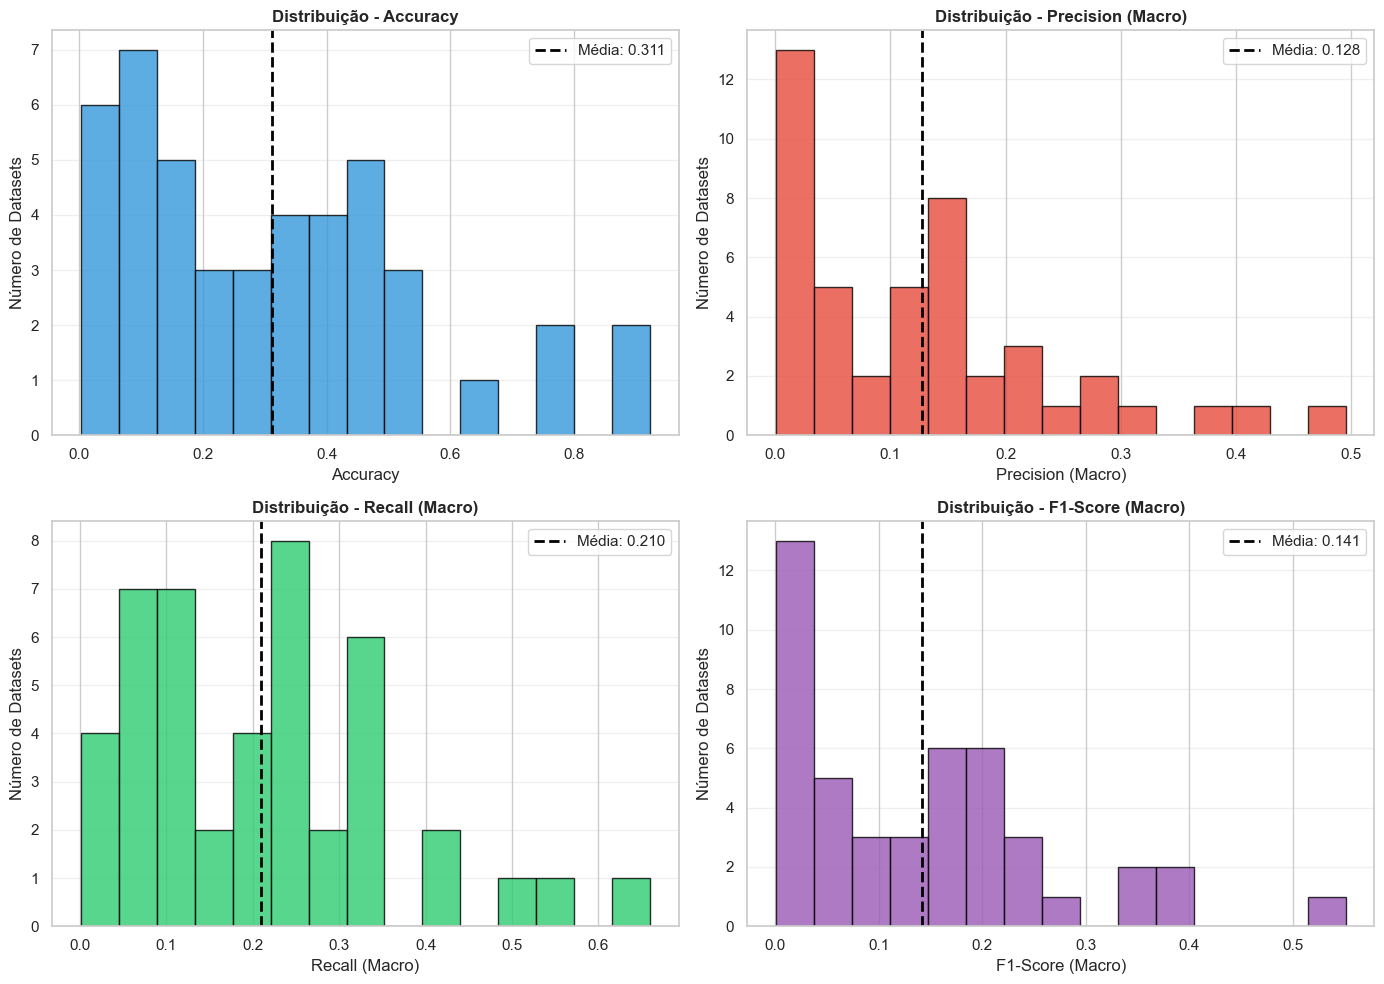

In [15]:

# Filtrar apenas execuções bem-sucedidas
df_logistic = pd.read_csv(r'resultados_processados\logistic\processado_grupo3_multiclass.csv')
df_lr_ok = df_logistic[df_logistic['Execution_Status'] == 'Success']

# Métricas a apresentar
metricas = ['Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']
titulos  = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']

# Tabela resumo
resumo_lr = pd.DataFrame({
    'Média':         [df_lr_ok[m].mean() for m in metricas],
    'Desvio Padrão': [df_lr_ok[m].std()  for m in metricas],
    'Mínimo':        [df_lr_ok[m].min()  for m in metricas],
    'Máximo':        [df_lr_ok[m].max()  for m in metricas],
}, index=titulos)

print(f"--- RESULTADOS DA LOGISTIC REGRESSION ({len(df_lr_ok)} datasets) ---")
print(resumo_lr.round(4).to_string())

# === PLOTAR OS GRÁFICOS PARA TODAS AS MÉTRICAS ===

# Criar uma figura com uma grade 2x2 (4 gráficos)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Achatar o array de eixos para facilitar o loop

# Cores diferentes para cada gráfico ficar mais visual
cores = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for i, (metrica, titulo) in enumerate(zip(metricas, titulos)):
    ax = axes[i]
    
    # Histograma para a métrica atual
    ax.hist(df_lr_ok[metrica], bins=15, color=cores[i], edgecolor='black', alpha=0.8)
    
    # Linha vertical mostrando a média
    media_metrica = df_lr_ok[metrica].mean()
    ax.axvline(media_metrica, color='black', linestyle='--', linewidth=2,
               label=f"Média: {media_metrica:.3f}")
    
    # Configurações do gráfico individual
    ax.set_xlabel(titulo)
    ax.set_ylabel('Número de Datasets')
    ax.set_title(f'Distribuição - {titulo}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Ajustar o layout para os gráficos não se sobreporem
plt.tight_layout()
plt.show()

### Análise dos Resultados: Por que a Regressão Logística falhou?

Os resultados agregados mostram um desempenho muito fraco (Accuracy de 0.31 e F1-Score Macro de 0.14). Para entender o porquê, basta analisarmos a base matemática do modelo testado.

A primeira abordagem foi desenhada como um classificador estritamente **binário**. Ela assenta em dois pilares que limitam a sua atuação em problemas multiclasse:
1. **Ativação Sigmoid:** Transforma a saída num único valor entre 0 e 1, preparado apenas para prever a presença ou ausência de uma única classe.
2. **Binary Cross-Entropy:** A função de custo calcula o erro assumindo a existência de apenas dois cenários possíveis (a classe principal e o seu oposto).

Quando aplicamos esta lógica puramente binária a datasets com múltiplas categorias, o modelo perde a capacidade de avaliar o contexto global. Ele não consegue traçar fronteiras de decisão complexas que separem várias classes simultaneamente, o que resulta num volume massivo de erros, especialmente na identificação das classes menos frequentes.

---

### O Próximo Passo: Regressão Logística Multinomial (Softmax)

Para resolver esta limitação estrutural, o passo seguinte é alterar o núcleo matemático do modelo para lidar nativamente com múltiplas classes, aplicando a **Regressão Logística Multinomial**.

As principais mudanças conceptuais são:

* **Matriz de Pesos:** Em vez de utilizar um único vetor de parâmetros, o modelo passa a utilizar uma matriz de pesos, conectando as variáveis de entrada (*features*) a todas as classes em simultâneo (utilizando *One-Hot Encoding* para os rótulos).
* **Ativação Softmax:** Substituímos a Sigmoid pela função Softmax. O modelo gera *scores* brutos (logits) para cada classe e transforma-os numa **distribuição de probabilidade válida** (onde a soma de todas as probabilidades resulta exatamente em 1 ou 100%).
* **Otimização Conjunta:** Através da *Categorical Cross-Entropy*, o modelo passa a calcular o erro avaliando todas as classes de uma só vez. 

Desta forma, as classes passam a competir entre si no mesmo espaço: se a probabilidade da Classe A sobe para 90%, restam apenas 10% para serem distribuídos pelas restantes. Isto elimina por completo as ambiguidades e permite ao algoritmo de otimização encontrar as fronteiras de decisão corretas para todo o dataset.

### 4. Comparação entre a Regressão Logística padrão e o Softmax

Contagem das taxas de sucesso: Logistic vs Softmax

In [16]:

# Carregar os dois CSVs (ambos já com pipeline de pré-processamento aplicado)
df_softmax  = pd.read_csv(r'resultados_processados\softMax\processado_softmax_grupo3_multiclass.csv')
df_weighted_softmax  = pd.read_csv(r'resultados_processados\weighted_softmax\processado_weighted_softmax_grupo3_multiclass.csv')

# Resumo de status
def get_status_summary(df, label):
    summary = df[df['Execution_Status'] == 'Success']['Execution_Status'].value_counts().to_frame()
    summary.columns = [label]
    return summary

status_comp = pd.concat([get_status_summary(df_logistic, 'Logistic (Fase 1)'),
                         get_status_summary(df_softmax,  'Softmax (Fase 2)'),
                         get_status_summary(df_weighted_softmax,  'Weighted_Softmax (Fase 3)')

                         ], axis=1).fillna(0)

display(status_comp)

,Logistic (Fase 1),Softmax (Fase 2),Weighted_Softmax (Fase 3)
Execution_Status,,,
Success,45,45,45


Comparação Logistic vs Softmax para TODAS as métricas (Grupo Multiclasse)


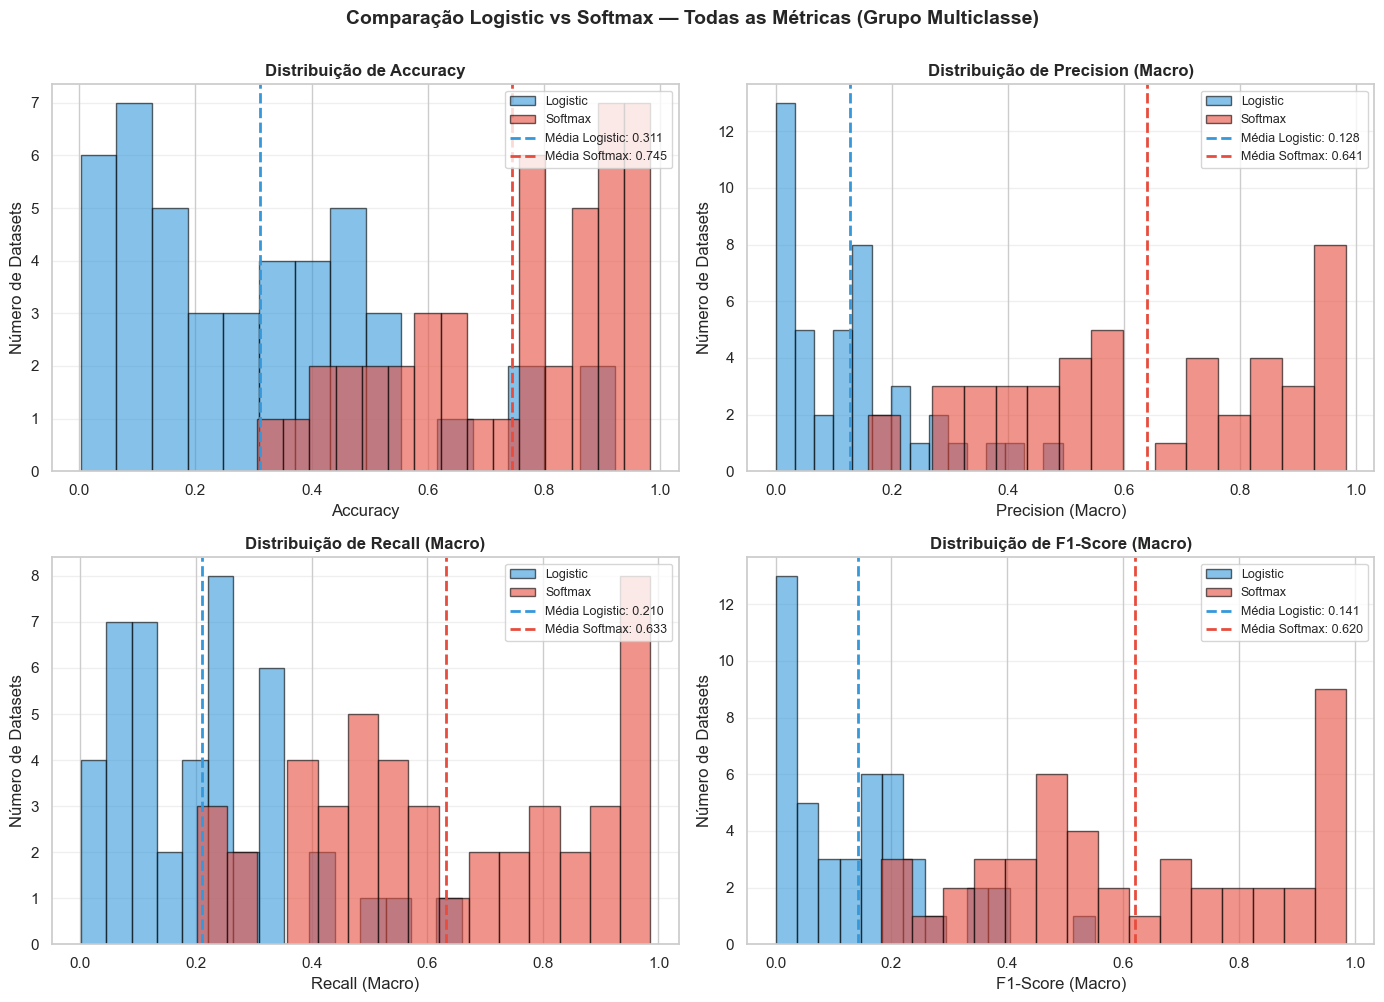


--- RESUMO NUMÉRICO ---


,Logistic (Média),Softmax (Média),Δ (Softmax − Logistic)
Accuracy,0.3115,0.7449,0.4334
Precision (Macro),0.1276,0.6411,0.5135
Recall (Macro),0.2101,0.6327,0.4226
F1-Score (Macro),0.1414,0.6202,0.4787


In [17]:
# Filtrar apenas execuções bem-sucedidas em ambos
df_lr_ok = df_logistic[df_logistic['Execution_Status'] == 'Success']
df_sm_ok = df_softmax[df_softmax['Execution_Status'] == 'Success']

# Lista de métricas a comparar
metricas = ['Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']
titulos = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # para iterar facilmente

for i, (metrica, titulo) in enumerate(zip(metricas, titulos)):
    ax = axes[i]
    
    # Histogramas sobrepostos
    ax.hist(df_lr_ok[metrica], bins=15, alpha=0.6, label='Logistic', 
            color='#3498db', edgecolor='black')
    ax.hist(df_sm_ok[metrica], bins=15, alpha=0.6, label='Softmax', 
            color='#e74c3c', edgecolor='black')
    
    # Linhas verticais nas médias
    media_lr = df_lr_ok[metrica].mean()
    media_sm = df_sm_ok[metrica].mean()
    ax.axvline(media_lr, color='#3498db', linestyle='--', linewidth=2,
               label=f'Média Logistic: {media_lr:.3f}')
    ax.axvline(media_sm, color='#e74c3c', linestyle='--', linewidth=2,
               label=f'Média Softmax: {media_sm:.3f}')
    
    ax.set_xlabel(titulo)
    ax.set_ylabel('Número de Datasets')
    ax.set_title(f'Distribuição de {titulo}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Comparação Logistic vs Softmax — Todas as Métricas (Grupo Multiclasse)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Tabela-resumo numérica por baixo do gráfico
resumo_metricas = pd.DataFrame({
    'Logistic (Média)': [df_lr_ok[m].mean() for m in metricas],
    'Softmax (Média)':  [df_sm_ok[m].mean() for m in metricas],
    'Δ (Softmax − Logistic)': [df_sm_ok[m].mean() - df_lr_ok[m].mean() for m in metricas]
}, index=titulos)

print("\n--- RESUMO NUMÉRICO ---")
display(resumo_metricas.round(4))

Comparação Logistic vs Softmax para TODAS as médias das métricas (Grupo Multiclasse)

Datasets comparáveis (correram em ambos algoritmos): 45


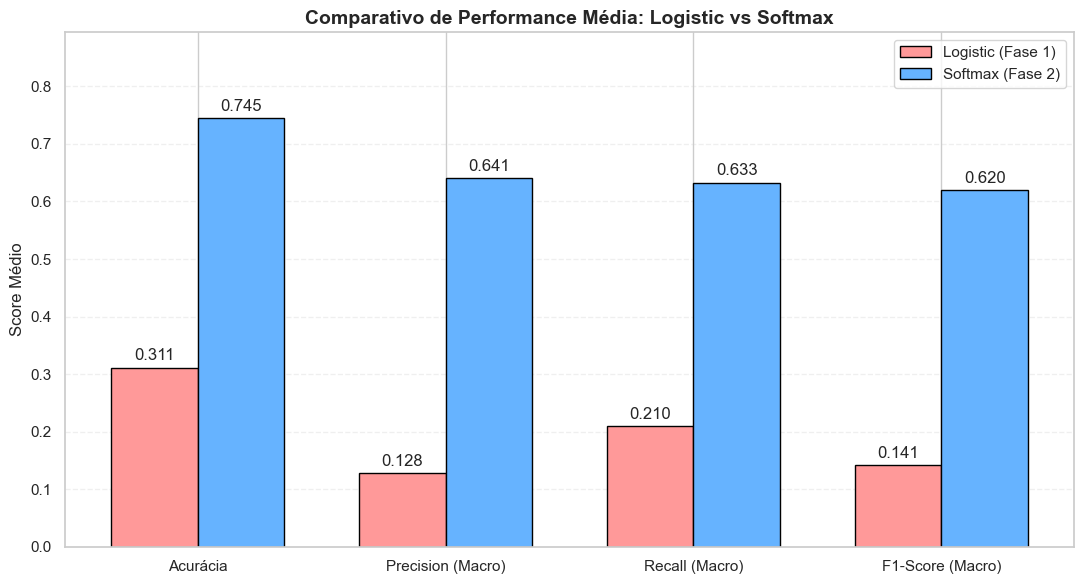

In [18]:
df_lr_ok = df_logistic[df_logistic['Execution_Status'] == 'Success']
df_sm_ok = df_softmax[df_softmax['Execution_Status'] == 'Success']

# Merge por nome de dataset (compara só os datasets que correram em AMBOS)
df_comparativo = pd.merge(
    df_lr_ok[['Dataset', 'Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']],
    df_sm_ok[['Dataset', 'Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']],
    on='Dataset',
    suffixes=('_LR', '_SM')
)

print(f"Datasets comparáveis (correram em ambos algoritmos): {len(df_comparativo)}")

# Calcular as médias para as 4 métricas
metricas = ['Acurácia', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
medias_lr = [
    df_comparativo['Accuracy_LR'].mean(),
    df_comparativo['Precision_Macro_LR'].mean(),
    df_comparativo['Recall_Macro_LR'].mean(),
    df_comparativo['F1_Macro_LR'].mean(),
]
medias_sm = [
    df_comparativo['Accuracy_SM'].mean(),
    df_comparativo['Precision_Macro_SM'].mean(),
    df_comparativo['Recall_Macro_SM'].mean(),
    df_comparativo['F1_Macro_SM'].mean(),
]

# Configuração das barras
x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
rects1 = ax.bar(x - width/2, medias_lr, width, label='Logistic (Fase 1)', 
                color='#ff9999', edgecolor='black')
rects2 = ax.bar(x + width/2, medias_sm, width, label='Softmax (Fase 2)',  
                color='#66b3ff', edgecolor='black')

# Adiciona rótulos de valores
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

# Textos
ax.set_ylabel('Score Médio')
ax.set_title('Comparativo de Performance Média: Logistic vs Softmax', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()

plt.ylim(0, max(max(medias_lr), max(medias_sm)) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Teste de Hipótese

#### Escolha do teste: Wilcoxon Signed-Rank
Para comparar dois classificadores avaliados nos **mesmos datasets**, a 
literatura de ML (Demšar, 2006) recomenda o **Wilcoxon Signed-Rank Test**:

- **Não-paramétrico**: não assume distribuição normal das diferenças.
- **Pareado**: compara dataset por dataset (não médias globais).
- **Robusto a outliers**.

### Formulação das hipóteses

- **H₀**: Logistic e Softmax têm performance equivalente.
- **H₁**: Logistic e Softmax têm performance diferente.
- **Nível de significância**: α = 0.05.

**Decisão:**
- p-value < 0.05 → rejeitamos H₀ → diferença estatisticamente significativa.
- p-value ≥ 0.05 → não rejeitamos H₀ → não há evidência de diferença.

Aplicamos o teste a cada uma das 4 métricas (Accuracy, Precision, Recall, F1).

In [19]:
# 1. Carregar os dois CSVs
df_logistic = pd.read_csv(r'resultados_processados\Logistic\processado_grupo3_multiclass.csv')
df_softmax  = pd.read_csv(r'resultados_processados\SoftMax\processado_softmax_grupo3_multiclass.csv')

# 2. Filtrar apenas datasets onde AMBOS algoritmos correram com sucesso
df_lr_ok = df_logistic[df_logistic['Execution_Status'] == 'Success']
df_sm_ok = df_softmax[df_softmax['Execution_Status']  == 'Success']

# 3. Fazer o merge para garantir comparação nos MESMOS datasets
df_pareado = pd.merge(
    df_lr_ok[['Dataset', 'Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']],
    df_sm_ok[['Dataset', 'Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']],
    on='Dataset',
    suffixes=('_LR', '_SM')
)

print(f"Datasets usados no teste: {len(df_pareado)}")
print()

# 4. Aplicar o Wilcoxon a cada métrica
metricas = ['Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']
resultados_teste = []

for metrica in metricas:
    valores_lr = df_pareado[f'{metrica}_LR'].values
    valores_sm = df_pareado[f'{metrica}_SM'].values
    
    # O teste de Wilcoxon (alternativa bilateral por defeito)
    stat, p_value = wilcoxon(valores_sm, valores_lr)
    
    # Determinar significância e quem vence
    significativo = "✓ Sim" if p_value < 0.05 else "✗ Não"
    media_lr = valores_lr.mean()
    media_sm = valores_sm.mean()
    delta    = media_sm - media_lr
    
    if p_value < 0.05:
        vencedor = "Softmax" if delta > 0 else "Logistic"
    else:
        vencedor = "Empate (sem evidência)"
    
    resultados_teste.append({
        'Métrica': metrica,
        'Média Logistic': round(media_lr, 4),
        'Média Softmax':  round(media_sm, 4),
        'Δ (SM − LR)':    round(delta, 4),
        'Statistic':      round(stat, 2),
        'p-value':        f"{p_value:.2e}",
        'Significativo (α=0.05)': significativo,
        'Conclusão':      vencedor
    })

# 5. Apresentar a tabela
df_resultado_teste = pd.DataFrame(resultados_teste)
print("--- RESULTADO DO WILCOXON SIGNED-RANK TEST: Logistic vs Softmax ---")
display(df_resultado_teste)

Datasets usados no teste: 45

--- RESULTADO DO WILCOXON SIGNED-RANK TEST: Logistic vs Softmax ---


,Métrica,Média Logistic,Média Softmax,Δ (SM − LR),Statistic,p-value,Significativo (α=0.05),Conclusão
0,Accuracy,0.3115,0.7449,0.4334,5.0,1.59e-08,✓ Sim,Softmax
1,Precision_Macro,0.1276,0.6411,0.5135,3.0,1.39e-08,✓ Sim,Softmax
2,Recall_Macro,0.2101,0.6327,0.4226,8.0,1.97e-08,✓ Sim,Softmax
3,F1_Macro,0.1414,0.6202,0.4787,3.0,1.39e-08,✓ Sim,Softmax


### Conclusão do Teste

Os quatro p-values obtidos situam-se na ordem de **10⁻⁸**, valores várias 
ordens de grandeza inferiores ao nível de significância estabelecido 
(α = 0.05). Rejeitamos portanto H₀ em todas as métricas testadas.

**Concluímos com elevada confiança estatística que o Softmax Regression é 
superior à Logistic Regression binária em problemas multiclasse.** A 
diferença observada — entre +0.42 e +0.51 pontos consoante a métrica — 
não é atribuível a variabilidade aleatória entre datasets, mas reflete 
uma vantagem real e sistemática do algoritmo.

Este resultado valida empiricamente a hipótese formulada na Fase 1: a 
Logistic binária, ao usar a função sigmoide que produz valores em {0, 1}, 
é estruturalmente incapaz de modelar problemas com mais de duas classes. 
O Softmax resolve essa limitação ao modelar explicitamente uma distribuição 
probabilística sobre todas as K classes.

A coerência entre as quatro métricas (todas indicam Softmax superior, com 
magnitudes de efeito comparáveis) reforça a robustez desta conclusão.

----

### 6. Otimização — Motivação da Proposta Original

O teste anterior confirmou que o Softmax supera a Logistic em problemas 
multiclasse com elevada significância estatística. Resolvida a limitação 
estrutural da Fase 1, podemos agora olhar criticamente para o Softmax 
em si e perguntar: **será este o melhor que se consegue?**

Ao examinar as médias do Softmax em detalhe, identifica-se um padrão 
revelador:

| Métrica           | Softmax |
|-------------------|---------|
| Accuracy          | 0.7449  |
| Precision (macro) | 0.6411  |
| Recall (macro)    | 0.6327  |
| F1-Score (macro)  | 0.6202  |
| **Gap Acc − F1**  | **0.1247** |

A Accuracy ultrapassa o F1 macro em cerca de **0.12 pontos**. Esta 
diferença é a assinatura clássica de **desbalanceamento de classes**: 
o modelo acumula acerto global nas classes maioritárias, enquanto o 
F1 macro — que pondera todas as classes equitativamente — revela que 
as minoritárias estão a ser sub-aprendidas.

### Causa-raiz teórica

A função de loss do Softmax, Categorical Cross-Entropy, atribui o mesmo 
peso a todas as amostras:

$$L_{\text{CE}} = -\frac{1}{N}\sum_{i=1}^{N} \sum_{c=1}^{K} y_{ic} \cdot \log(p_{ic})$$

Se uma classe tem 1000 amostras e outra 50, a primeira contribui com 
20× mais sinal para o gradiente. O modelo aprende preferencialmente os 
padrões maioritários — não por escolha, mas por aritmética.

### Proposta original: Weighted Softmax Regression

Para corrigir este viés, atribuímos a cada classe um peso inversamente 
proporcional à sua frequência. A loss passa a ser:

$$L_{\text{WCE}} = -\frac{1}{N}\sum_{i=1}^{N} \sum_{c=1}^{K} w_c \cdot y_{ic} \cdot \log(p_{ic})$$

com pesos calculados automaticamente a partir das contagens:

$$w_c = \frac{N}{K \cdot n_c}$$

onde $N$ é o número total de amostras, $K$ o número de classes, e $n_c$ 
o número de amostras na classe $c$.

A fórmula tem uma propriedade matemática útil: **iguala a contribuição 
total de cada classe no gradiente**, independentemente da sua frequência. 
Classes raras recebem pesos altos; classes frequentes recebem pesos 
baixos; o produto $w_c \cdot n_c$ é constante para todas.

### Hipótese a testar

* Em problemas multiclasse com desbalanceamento, o Weighted Softmax melhora o F1 macro relativamente ao Softmax padrão, possivelmente à custa de uma ligeira perda em Accuracy global.

### Formulação das hipóteses

- **H₀**: Softmax e Weighted Softmax têm performance equivalente.
- **H₁**: Softmax e Weighted Softmax têm performance diferente.
- **Nível de significância**: α = 0.05.

**Decisão:**
- p-value < 0.05 → rejeitamos H₀ → diferença estatisticamente significativa.
- p-value ≥ 0.05 → não rejeitamos H₀ → não há evidência de diferença.

Aplicamos o teste a cada uma das 4 métricas, adotando **F1 macro como 
métrica primária** por ser insensível ao desbalanceamento; as restantes 
servem de validação cruzada.

Comparação Softmax vs Weighted Softmax: todas as métricas (Grupo Multiclasse)

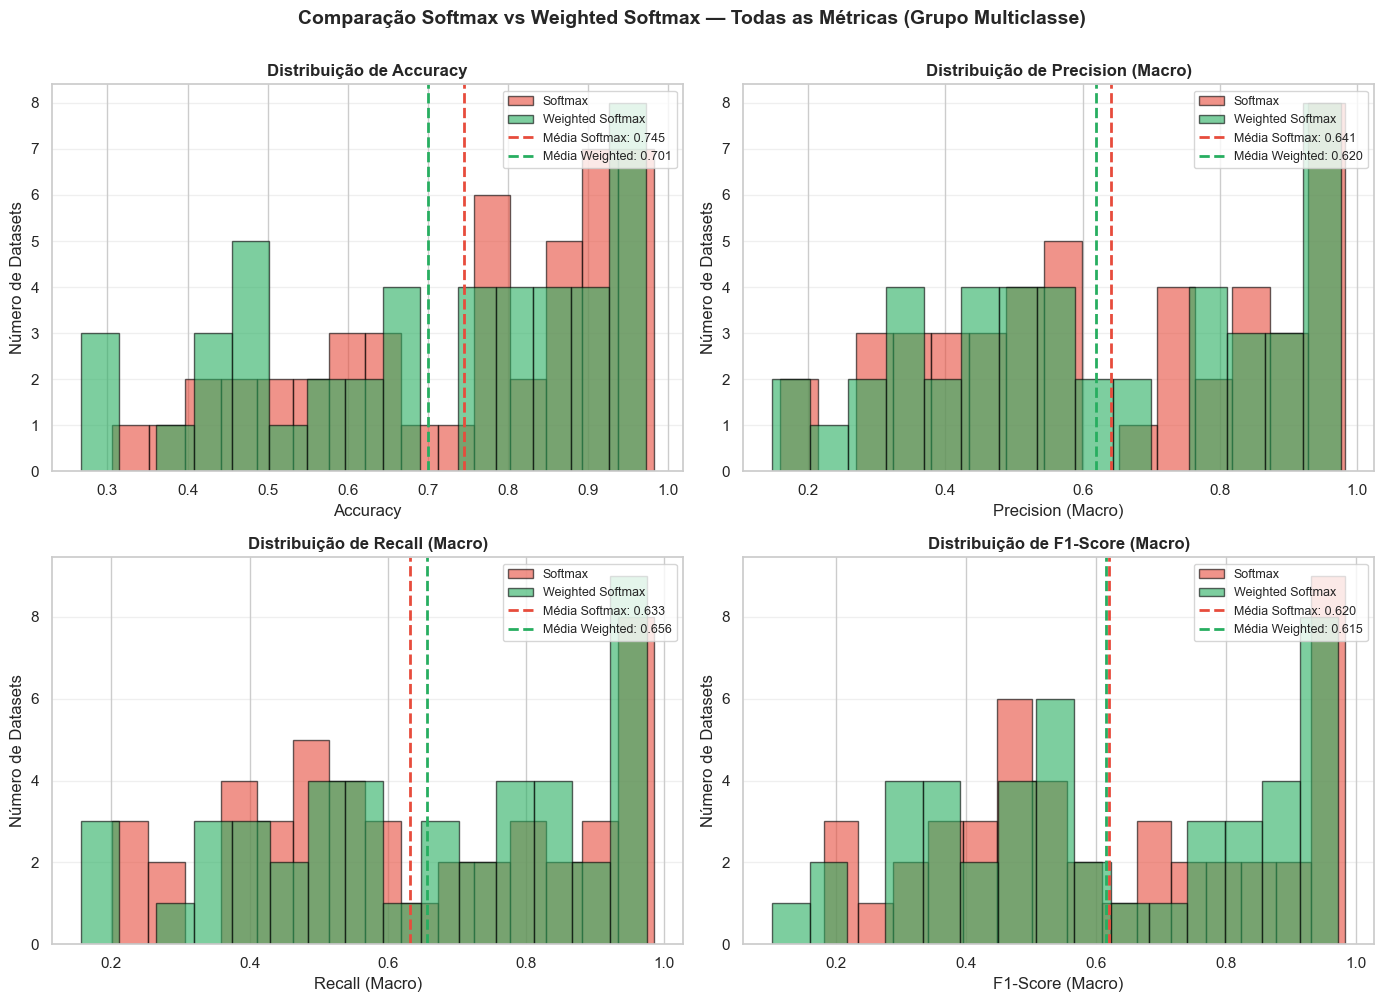


--- RESUMO NUMÉRICO ---


,Softmax (Média),Weighted Softmax (Média),Δ (Weighted − Softmax)
Accuracy,0.7449,0.7007,-0.0442
Precision (Macro),0.6411,0.6201,-0.0210
Recall (Macro),0.6327,0.6561,0.0234
F1-Score (Macro),0.6202,0.6151,-0.0051


In [20]:
# Carregar os dois CSVs
df_softmax  = pd.read_csv(r'resultados_processados\softmax\processado_softmax_grupo3_multiclass.csv')
df_weighted = pd.read_csv(r'resultados_processados\weighted_softmax\processado_weighted_softmax_grupo3_multiclass.csv')

# Filtrar apenas execuções bem-sucedidas
df_sm_ok = df_softmax[df_softmax['Execution_Status']   == 'Success']
df_w_ok  = df_weighted[df_weighted['Execution_Status'] == 'Success']

# Lista de métricas a comparar
metricas = ['Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']
titulos  = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (metrica, titulo) in enumerate(zip(metricas, titulos)):
    ax = axes[i]
    
    ax.hist(df_sm_ok[metrica], bins=15, alpha=0.6, label='Softmax',          
            color='#e74c3c', edgecolor='black')
    ax.hist(df_w_ok[metrica],  bins=15, alpha=0.6, label='Weighted Softmax', 
            color='#27ae60', edgecolor='black')
    
    media_sm = df_sm_ok[metrica].mean()
    media_w  = df_w_ok[metrica].mean()
    ax.axvline(media_sm, color='#e74c3c', linestyle='--', linewidth=2,
               label=f'Média Softmax: {media_sm:.3f}')
    ax.axvline(media_w,  color='#27ae60', linestyle='--', linewidth=2,
               label=f'Média Weighted: {media_w:.3f}')
    
    ax.set_xlabel(titulo)
    ax.set_ylabel('Número de Datasets')
    ax.set_title(f'Distribuição de {titulo}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Comparação Softmax vs Weighted Softmax — Todas as Métricas (Grupo Multiclasse)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Tabela-resumo numérica
resumo = pd.DataFrame({
    'Softmax (Média)':         [df_sm_ok[m].mean() for m in metricas],
    'Weighted Softmax (Média)':[df_w_ok[m].mean()  for m in metricas],
    'Δ (Weighted − Softmax)':  [df_w_ok[m].mean() - df_sm_ok[m].mean() for m in metricas]
}, index=titulos)

print("\n--- RESUMO NUMÉRICO ---")
display(resumo.round(4))

Aplica o teste de Wilcoxon Signed-Rank pareado às 4 métricas para verificar se a diferença entre Logistic e Softmax nos mesmos 45 datasets é estatisticamente significativa, e mostra os p-values e o vencedor de cada métrica numa tabela.

In [21]:
# 1. Carregar os dois CSVs
df_softmax  = pd.read_csv(r'resultados_processados\softmax\processado_softmax_grupo3_multiclass.csv')
df_weighted = pd.read_csv(r'resultados_processados\weighted_softmax\processado_weighted_softmax_grupo3_multiclass.csv')

# 2. Filtrar apenas datasets onde AMBOS algoritmos correram com sucesso
df_sm_ok = df_softmax[df_softmax['Execution_Status']   == 'Success']
df_w_ok  = df_weighted[df_weighted['Execution_Status'] == 'Success']

# 3. Merge para garantir comparação pareada nos MESMOS datasets
df_pareado = pd.merge(
    df_sm_ok[['Dataset', 'Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']],
    df_w_ok[['Dataset', 'Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']],
    on='Dataset',
    suffixes=('_SM', '_W')
)

print(f"Datasets usados no teste: {len(df_pareado)}")
print()

# 4. Aplicar o Wilcoxon a cada métrica
metricas = ['Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']
resultados_teste = []

for metrica in metricas:
    valores_sm = df_pareado[f'{metrica}_SM'].values
    valores_w  = df_pareado[f'{metrica}_W'].values
    
    stat, p_value = wilcoxon(valores_w, valores_sm, zero_method='zsplit')
    
    media_sm = valores_sm.mean()
    media_w  = valores_w.mean()
    delta    = media_w - media_sm
    
    significativo = "✓ Sim" if p_value < 0.05 else "✗ Não"
    
    if p_value < 0.05:
        vencedor = "Weighted Softmax" if delta > 0 else "Softmax"
    else:
        vencedor = "Empate (sem evidência)"
    
    resultados_teste.append({
        'Métrica': metrica,
        'Média Softmax':   round(media_sm, 4),
        'Média Weighted':  round(media_w, 4),
        'Δ (W − SM)':      round(delta, 4),
        'Statistic':       round(stat, 2),
        'p-value':         f"{p_value:.2e}",
        'Significativo (α=0.05)': significativo,
        'Conclusão':       vencedor
    })

df_resultado_teste = pd.DataFrame(resultados_teste)
print("--- RESULTADO DO WILCOXON SIGNED-RANK TEST: Softmax vs Weighted Softmax ---")
display(df_resultado_teste)

Datasets usados no teste: 45

--- RESULTADO DO WILCOXON SIGNED-RANK TEST: Softmax vs Weighted Softmax ---


,Métrica,Média Softmax,Média Weighted,Δ (W − SM),Statistic,p-value,Significativo (α=0.05),Conclusão
0,Accuracy,0.7449,0.7007,-0.0442,159.5,5.32e-05,✓ Sim,Softmax
1,Precision_Macro,0.6411,0.6201,-0.0210,315.5,2.26e-02,✓ Sim,Softmax
2,Recall_Macro,0.6327,0.6561,0.0234,410.5,2.27e-01,✗ Não,Empate (sem evidência)
3,F1_Macro,0.6202,0.6151,-0.0051,371.5,9.94e-02,✗ Não,Empate (sem evidência)


### Conclusão — Softmax vs Weighted Softmax

O teste revela um **padrão diferenciado entre métricas** que importa 
interpretar em conjunto:

| Métrica          | Δ (W − SM) | p-value    | Significativo | Conclusão     |
|------------------|------------|------------|---------------|---------------|
| Accuracy         | −0.044     | 5.3 × 10⁻⁵ | ✓ Sim         | Softmax vence |
| Precision (macro)| −0.021     | 2.3 × 10⁻² | ✓ Sim         | Softmax vence |
| Recall (macro)   | +0.023     | 0.23       | ✗ Não         | Sem evidência |
| F1 (macro)       | −0.005     | 0.099      | ✗ Não         | Sem evidência |

**A mecânica teórica do class weighting funcionou exactamente como 
previsto.** Observa-se com clareza o trade-off recall vs precision que a 
teoria antecipa:

- **Recall aumentou** (+0.023): o modelo identifica mais exemplos de 
  classes raras, como pretendido.
- **Precision diminuiu** (−0.021, p < 0.05): em troca, faz mais falsos 
  positivos nessas mesmas classes.
- **Accuracy diminuiu** (−0.044, p < 10⁻⁴): perde acerto global ao 
  reequilibrar o gradiente.

A implementação está, portanto, **matematicamente correcta** — o 
algoritmo produz o efeito teórico esperado.

Quanto ao **efeito líquido em F1 macro, este é praticamente nulo** 
(Δ = −0.005, p = 0.10). Como F1 é a média harmónica de precision e 
recall, e estes movem-se em direções opostas com magnitudes semelhantes, 
o resultado é neutro: não rejeitamos H₀ para a métrica primária.

#### Interpretação geral

A proposta produz alterações estatisticamente significativas no 
comportamento do modelo (em Accuracy e Precision), mas **estas alterações 
não constituem uma melhoria líquida** nas métricas relevantes para 
classificação equilibrada. 

A explicação mais provável é que **o desbalanceamento médio dos 45 
datasets não é suficientemente severo** para que o reequilíbrio compense 
as suas próprias desvantagens. A literatura reconhece o class weighting 
como eficaz em problemas com ratios elevados (e.g. > 1:50); a maioria 
dos datasets do benchmark estará abaixo desse limiar. Concluímos, portanto, que para o conjunto de datasets multiclasse, o algoritmo Softmax padrão é a escolha mais adequada no agregado.

---

### 7. Caso de Estudo
#### Decidimos mostrar os resultados do Weighted Softmax vs Softmax em um exemplo de dataset desbalanceado dentro do multiclasse.

Carrega o dataset Page-Blocks e mostra as suas dimensões, primeiras linhas e distribuição de classes.

In [22]:
# Carregar o dataset Page-Blocks
dataset_alvo = "dataset_30_page-blocks.csv"
df_page_blocks = pd.read_csv(os.path.join("datasets/multiclass_classification/", dataset_alvo))

print(f"Dimensões do dataset: {df_page_blocks.shape}")
print(f"\nPrimeiras linhas:")
display(df_page_blocks.head())

print(f"\nDistribuição de classes:")
print(df_page_blocks.iloc[:, -1].value_counts())

Dimensões do dataset: (5473, 11)

Primeiras linhas:


,height,lenght,area,eccen,p_black,p_and,mean_tr,blackpix,blackand,wb_trans,class
0,5,7,35,1.400,0.400,0.657,2.33,14,23,6,1
1,6,7,42,1.167,0.429,0.881,3.60,18,37,5,1
2,6,18,108,3.000,0.287,0.741,4.43,31,80,7,1
3,5,7,35,1.400,0.371,0.743,4.33,13,26,3,1
4,6,3,18,0.500,0.500,0.944,2.25,9,17,4,1



Distribuição de classes:
class
1    4913
2     329
5     115
4      88
3      28
Name: count, dtype: int64


Aplica o pipeline da Fase 1 (imputação, encoding, split 80/20 estratificado, normalização Z-score), treina os dois modelos (Softmax e Weighted Softmax) e mostra a tabela de pesos por classe.

In [23]:
# === Pré-processamento do Page-Blocks (pipeline da Fase 1) ===
X_orig = df_page_blocks.iloc[:, :-1]
y_orig = df_page_blocks.iloc[:, -1]

# Passo A: Limpeza de nulos
X_limpo, _ = imputar_nulos(X_orig)

# Passo B: Encoding (mantemos o pipeline consistente, mesmo sem categóricas)
_, X_numpy, y_numpy, _ = aplicar_encoding(X_limpo, y_orig)

# Passo C: Split treino/teste 80/20 com estratificação
try:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_numpy, y_numpy, test_size=0.2, random_state=42, stratify=y_numpy
    )
    print("Split com stratify: OK")
except ValueError as e:
    print(f"Aviso: stratify falhou ({e}). Usando split aleatório.")
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_numpy, y_numpy, test_size=0.2, random_state=42
    )

# Passo D: Normalização Z-score
X_tr_s, X_te_s, _, _ = normalizar_zscore(X_tr, X_te)

# Verificação dos dados
print(f"X_treino shape: {X_tr_s.shape}")
print(f"X_teste  shape: {X_te_s.shape}")
print(f"\nDistribuição de classes no treino:")
classes_tr, contagens_tr = np.unique(y_tr, return_counts=True)
for c, n in zip(classes_tr, contagens_tr):
    print(f"  {c}: {n} amostras")

# === Treino dos dois modelos ===
print("\n>>> Treinando Softmax baseline...")
model_sm = SoftmaxRegression(lr=0.01, max_iters=1000, weighted=False)
model_sm.fit(X_tr_s, y_tr)
print("OK!")

print("\n>>> Treinando Weighted Softmax...")
model_w = SoftmaxRegression(lr=0.01, max_iters=1000, weighted=True)
model_w.fit(X_tr_s, y_tr)
print("OK!")

# === Tabela comparativa dos pesos por classe ===
print("\n--- PESOS POR CLASSE: Softmax vs Weighted Softmax ---")
print(f"{'Classe':<8}{'N_amostras':<13}{'Peso Softmax':<16}{'Peso Weighted':<15}")
print("-" * 55)
for c, n, peso_w in zip(classes_tr, contagens_tr, model_w.class_weights):
    peso_sm = 1.0  # implícito no Softmax padrão: todas as classes pesam igual
    print(f"  {c:<6}{n:<13}{peso_sm:<16.3f}{peso_w:<15.3f}")

Split com stratify: OK
X_treino shape: (4378, 10)
X_teste  shape: (1095, 10)

Distribuição de classes no treino:
  1: 3930 amostras
  2: 263 amostras
  3: 23 amostras
  4: 70 amostras
  5: 92 amostras

>>> Treinando Softmax baseline...
OK!

>>> Treinando Weighted Softmax...
OK!

--- PESOS POR CLASSE: Softmax vs Weighted Softmax ---
Classe  N_amostras   Peso Softmax    Peso Weighted  
-------------------------------------------------------
  1     3930         1.000           0.223          
  2     263          1.000           3.329          
  3     23           1.000           38.070         
  4     70           1.000           12.509         
  5     92           1.000           9.517          


Faz previsões no conjunto de teste com ambos os modelos e calcula as 4 métricas (Accuracy, Precision, Recall, F1) para comparar Softmax vs Weighted Softmax.

In [24]:
# === Previsões no conjunto de teste ===
y_pred_sm = model_sm.predict(X_te_s)
y_pred_w  = model_w.predict(X_te_s)

# === Cálculo das 4 métricas para cada modelo ===
metricas_caso = pd.DataFrame({
    'Softmax (baseline)': [
        accuracy_score(y_te, y_pred_sm),
        precision_score(y_te, y_pred_sm, average='macro', zero_division=0),
        recall_score(y_te, y_pred_sm, average='macro', zero_division=0),
        f1_score(y_te, y_pred_sm, average='macro', zero_division=0),
    ],
    'Weighted Softmax': [
        accuracy_score(y_te, y_pred_w),
        precision_score(y_te, y_pred_w, average='macro', zero_division=0),
        recall_score(y_te, y_pred_w, average='macro', zero_division=0),
        f1_score(y_te, y_pred_w, average='macro', zero_division=0),
    ]
}, index=['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)'])

# Calcular o delta (diferença Weighted − Softmax)
metricas_caso['Δ (W − SM)'] = metricas_caso['Weighted Softmax'] - metricas_caso['Softmax (baseline)']

print(f"--- MÉTRICAS NO DATASET Page-Blocks (test set, {len(y_te)} amostras) ---")
display(metricas_caso.round(4))

--- MÉTRICAS NO DATASET Page-Blocks (test set, 1095 amostras) ---


,Softmax (baseline),Weighted Softmax,Δ (W − SM)
Accuracy,0.9352,0.7543,-0.1808
Precision (macro),0.8246,0.4631,-0.3616
Recall (macro),0.4511,0.8097,0.3586
F1 (macro),0.5188,0.4949,-0.0239


### Conclusão do Estudo de Caso

Aplicámos a nossa proposta ao Page-Blocks (IR=175, um dos datasets mais 
desbalanceados do benchmark) para ilustrar empiricamente o comportamento 
do Weighted Softmax. Os resultados são:

| Métrica          | Softmax | Weighted | Δ        | Interpretação                |
|------------------|---------|----------|----------|------------------------------|
| Accuracy         | 0.9352  | 0.7543   | −0.1808  | Custo do reequilíbrio        |
| Precision (macro)| 0.8246  | 0.4631   | −0.3616  | Mais falsos positivos        |
| **Recall (macro)** | **0.4511** | **0.8097** | **+0.3586** | **Ganho dramático** |
| F1 (macro)       | 0.5188  | 0.4949   | −0.0239  | Trade-off quase neutro       |

A análise mostra com clareza o **trade-off fundamental do class weighting**:

- O Softmax baseline alcança 93.52% de Accuracy — mas o Recall macro de 
  apenas 45.11% revela que essa "boa" performance vem de acertar 
  quase tudo na classe maioritária, **ignorando grande parte das classes restantes**.

- O Weighted Softmax inverte este comportamento: o Recall macro sobe 
  para 80.97% (+35.86 pontos!), demonstrando que o modelo passa a 
  identificar exemplos das classes raras. O preço é uma quebra em 
  Accuracy e Precision, sinal de que o modelo agora arrisca mais 
  palpites nas classes minoritárias.

Este caso ilustra a essência da nossa proposta: **não é uma melhoria 
universal, mas uma alteração deliberada do que o modelo prioriza**. 
Em aplicações onde identificar classes raras é mais importante que 
maximizar acerto global (e.g. deteção de fraude, diagnóstico médico), 
o Weighted Softmax é a escolha correcta.

### 8. Conclusão Geral

O projeto seguiu **três etapas encadeadas**:

1. **Logistic Regression** — implementámos o algoritmo da Fase 1 e identificámos a sua limitação estrutural em problemas multiclasse.

2. **Softmax Regression** — estendemos o algoritmo para K classes, com melhoria massiva validada estatisticamente (Wilcoxon, *p* < 10⁻⁸ em todas as métricas).

3. **Weighted Softmax (proposta original)** — introduzimos pesos por classe para mitigar o desbalanceamento. A proposta produziu o trade-off teórico esperado — *Recall* sobe, *Accuracy* e *Precision* descem — sem ganho líquido em *F1 macro* no agregado dos 45 datasets. O estudo de caso no **Page-Blocks** demonstrou, contudo, a sua aplicabilidade em cenários onde identificar classes raras é prioritário.

> O maior valor do trabalho está no **rigor metodológico**: cada hipótese foi formulada, testada estatisticamente e honestamente reportada — incluindo as que não se confirmaram.

#### Referências

- Implementação base inspirada em [rushter/MLAlgorithms](https://github.com/rushter/MLAlgorithms) (referência indicada no enunciado), com modificações substanciais.
- Demšar, J. (2006). *Statistical Comparisons of Classifiers over Multiple Data Sets.* Journal of Machine Learning Research, 7, 1–30. — protocolo do teste estatístico utilizado.